In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("C:/Users/zekhe/OneDrive/Documents/bank/bank-full.csv", delimiter = ";")

In [5]:
df.head

<bound method NDFrame.head of        age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [9]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


<Axes: xlabel='count', ylabel='default'>

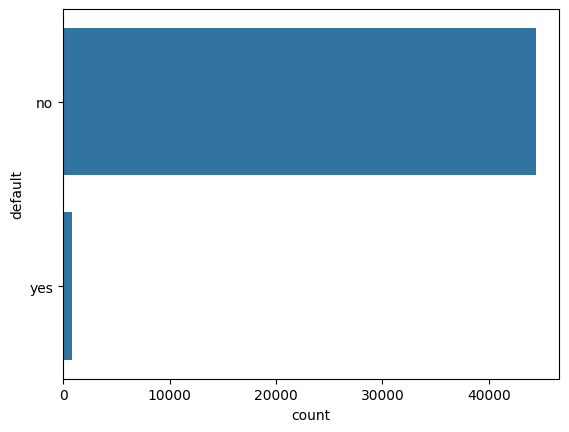

In [12]:
sns.countplot(df["default"])

In [18]:
(df.default.isin(["yes"]).sum())/len(df)*100

np.float64(1.8026586450200173)

##### 1.80% of the clients are defaulters

In [28]:
(df.contact.isin(["unknown"]).sum())/len(df)*100

np.float64(28.798301298356595)

##### 28.8% of clients are unreachable. 

In [85]:
(df["poutcome"] == "unknown").sum()/len(df)*100

np.float64(81.74780473778506)

##### 81.7% of previous outcome is unknown.

In [43]:
(df["y"] == "yes").sum()/len(df)*100

np.float64(11.698480458295547)

##### 11.7% of clients contacted subscribed.

In [45]:
df["dual_loan"] = (df["housing"] == "yes") & (df["loan"] == "yes")

In [126]:
df["no_loan"] = (df["housing"] == "no") & (df["loan"] == "no")

In [127]:
df["housing_only"] = (df["housing"] == "yes") & (df["loan"] == "no")

In [128]:
df["loan_only"] = (df["housing"] == "no") & (df["loan"] == "yes")

Text(0.5, 1.0, 'Marital status vs default rate')

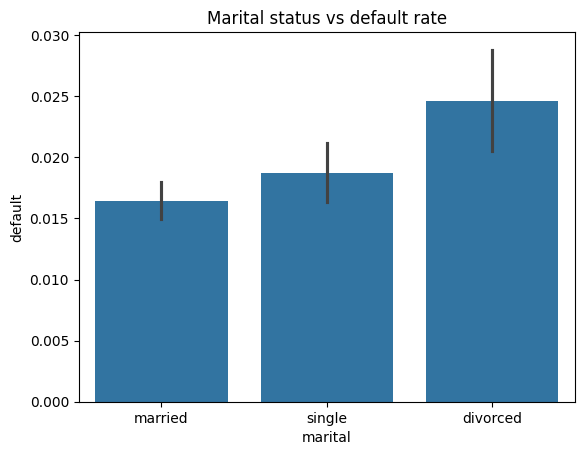

In [120]:
sns.barplot(x= df["marital"], y= df["default"].map({"yes":1, "no":0}))
plt.title("Marital status vs default rate")

In [119]:
((df["marital"] == "divorced") & (df["default"] == "yes")).sum()/((df["default"] == "yes").sum())*100

np.float64(15.70552147239264)

##### 15.71% of defaulters are divorced.

Text(0.5, 1.0, 'Age distribution of defaulters')

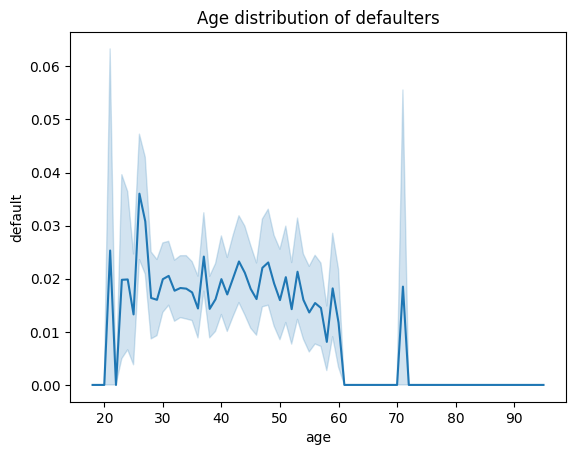

In [121]:
sns.lineplot(x= df["age"], y= df["default"].map({"yes":1, "no":0}))
plt.title("Age distribution of defaulters")

##### Most defaulters are aged around 28.

Text(0.5, 1.0, 'Job vs default rate')

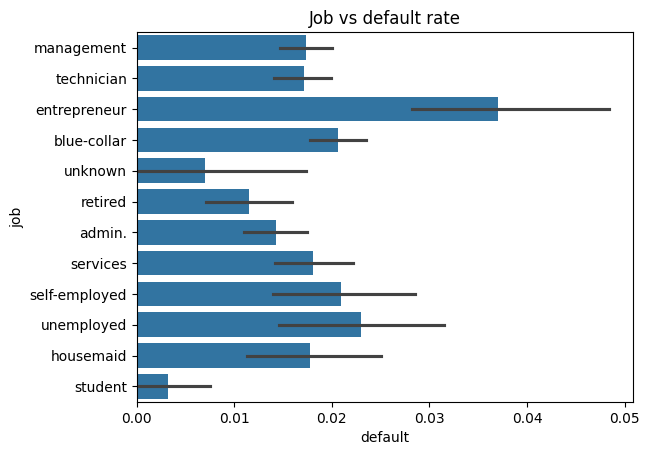

In [122]:
sns.barplot(y="job", x=df["default"].map({"yes":1, "no":0}), data=df, orient="h")
plt.title("Job vs default rate")

##### Most defaulters are entreprenuers.

Text(0.5, 1.0, 'Contact vs default rate')

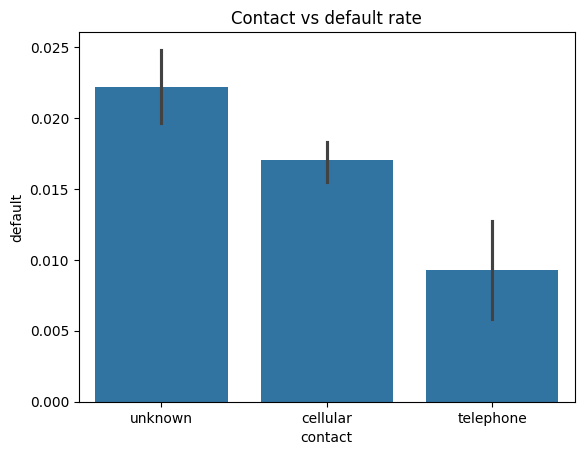

In [123]:
sns.barplot(x= df["contact"], y= df["default"].map({"yes":1, "no":0}))
plt.title("Contact vs default rate")

In [108]:
(((df["default"] == "yes") & (df["contact"] == "unknown")).sum())/((df["default"] == "yes").sum())*100

np.float64(35.4601226993865)

##### 35.46% defaulters were clients that the bank had no contact details for.

In [140]:
((df["dual_loan"] == True) & (df["default"] == "yes")).sum()/((df["default"] == "yes").sum())*100

np.float64(16.319018404907975)

##### 16.32% of defaulters are dual loan holders.

In [139]:
((df["loan_only"] == True) & (df["default"] == "yes")).sum()/((df["default"] == "yes").sum())*100

np.float64(20.61349693251534)

##### 20.61% of defaulters are clients who hold only personal loans.

<Axes: xlabel='housing_only', ylabel='default'>

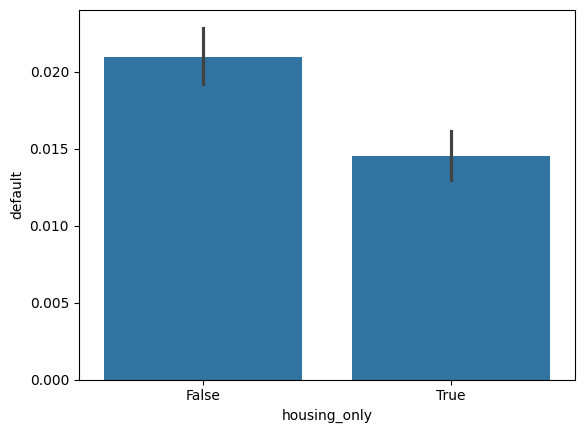

In [134]:
sns.barplot(x= df["housing_only"], y= df["default"].map({"yes":1, "no":0}))

In [141]:
((df["housing_only"] == True) & (df["default"] == "yes")).sum()/((df["default"] == "yes").sum())*100

np.float64(37.05521472392638)

##### 37.06% of the defaulters are clients that hold housing loans only.

<Axes: xlabel='no_loan', ylabel='default'>

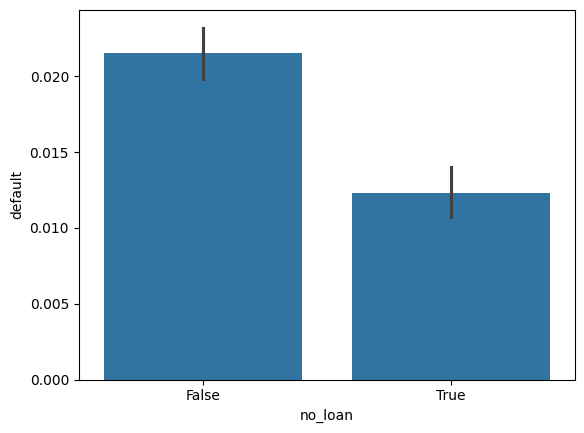

In [135]:
sns.barplot(x= df["no_loan"], y= df["default"].map({"yes":1, "no":0}))

In [142]:
((df["no_loan"] == True) & (df["default"] == "yes")).sum()/((df["default"] == "yes").sum())*100

np.float64(26.012269938650306)

##### 26.01% of defaulters are clients who don't have loans with the bank.

Text(0.5, 1.0, 'Education vs default rate')

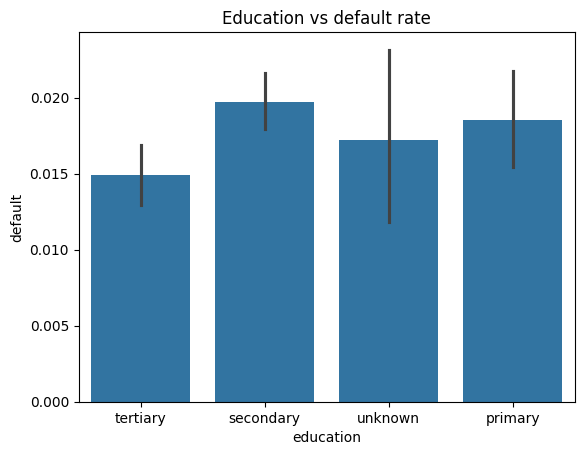

In [125]:
sns.barplot(x= df["education"], y= df["default"].map({"yes":1, "no":0}))
plt.title("Education vs default rate")

##### Clients with secondary level education form the highest group of defaulters.

In [152]:
df.groupby('default')['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
no,44396.0,1389.806424,3063.275425,-4057.0,84.0,468.0,1462.25,102127.0
yes,815.0,-137.624540,906.704678,-8019.0,-339.0,-7.0,15.00,16486.0


Text(0.5, 1.0, 'pdays vs y')

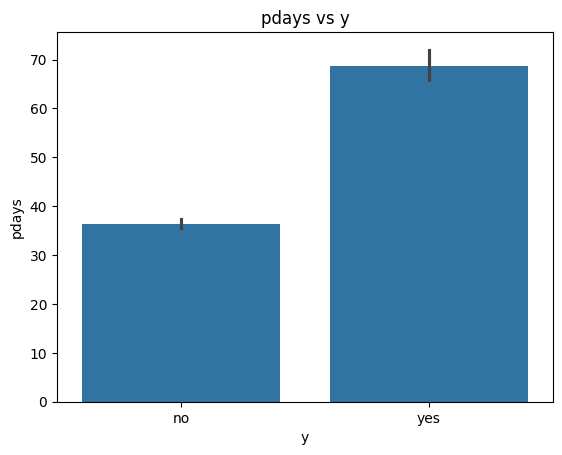

In [153]:
sns.barplot(x= df["y"], y= df["pdays"])
plt.title("pdays vs y")

##### Most clients that subscribed had been last contacted in over 60 days. 

Text(0.5, 1.0, 'poutcome vs y')

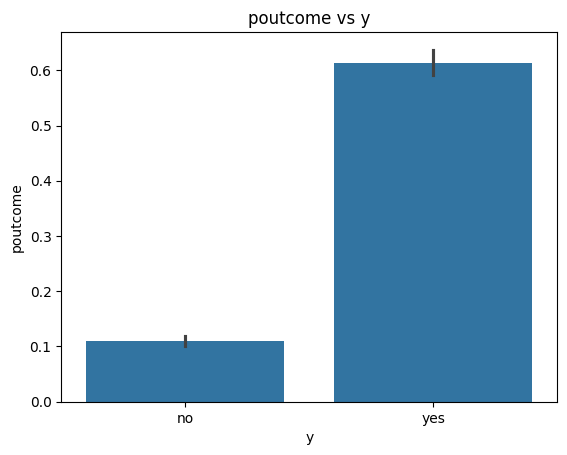

In [154]:
sns.barplot(x= df["y"], y= df["poutcome"].map({"success":1, "failure":0}))
plt.title("poutcome vs y")

In [156]:
((df["poutcome"] == "success") & (df["y"] == "yes")).sum()/((df["y"] == "yes").sum())*100

np.float64(18.491208167895632)

##### 18.49% clients who subscribed had a successful outcome in the previous marketing campaign.

Text(0.5, 1.0, 'duration vs y')

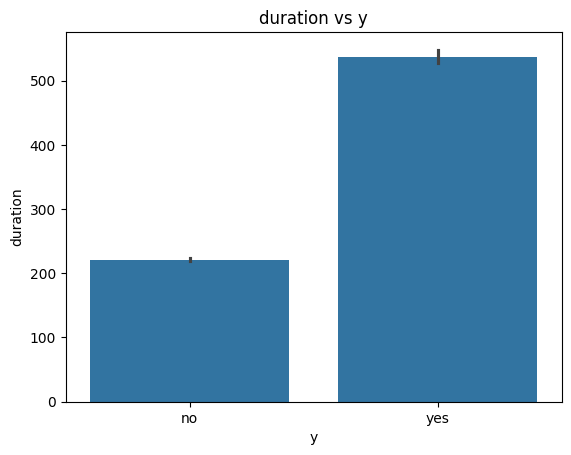

In [155]:
sns.barplot(x= df["y"], y= df["duration"])
plt.title("duration vs y")

##### Most of the clients who subscribed were the ones that stayed on the call longer.

Text(0.5, 1.0, 'y vs previous')

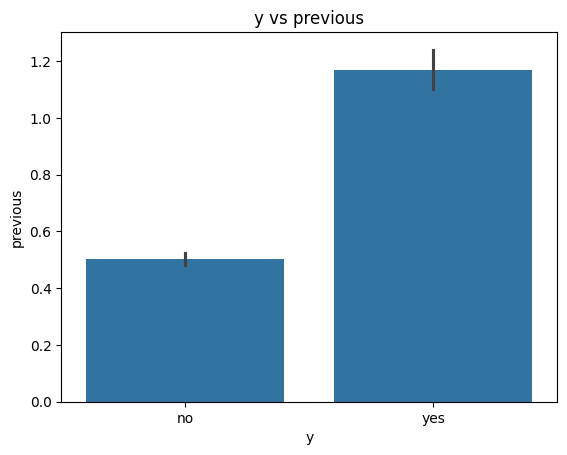

In [178]:
sns.barplot(x= df["y"], y= df["previous"])
plt.title("y vs previous")

##### Most successful clients were ones that were contacted more frequently before this campaign.

Text(0.5, 1.0, 'y vs campaign')

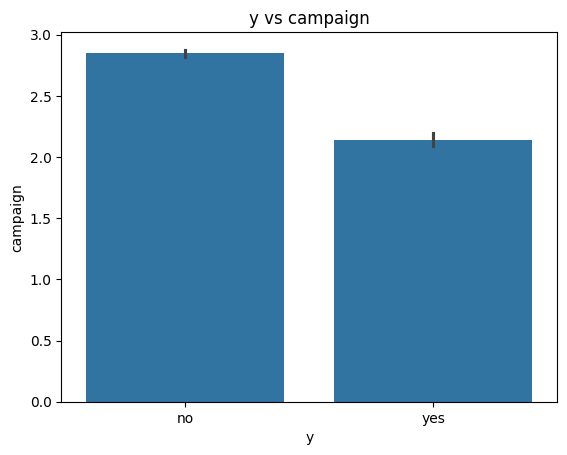

In [179]:
sns.barplot(x= df["y"], y= df["campaign"])
plt.title("y vs campaign")

##### Most clients who were contacted more frequently did not subscribe.

Text(0.5, 1.0, 'y vs marital')

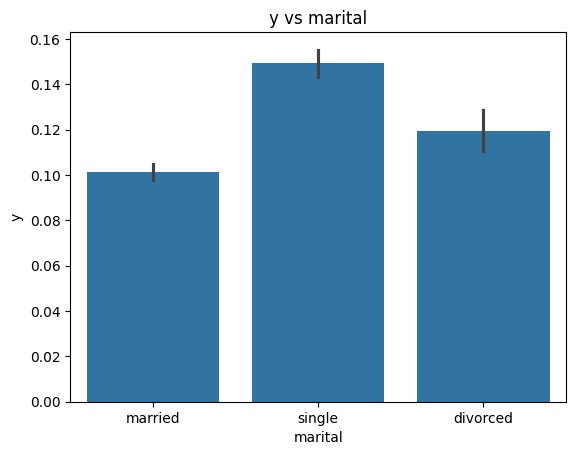

In [157]:
sns.barplot(x= df["marital"], y = df["y"].map({"yes":1, "no":0}))
plt.title("y vs marital")

##### Most of the subscribers were single clients.

Text(0.5, 1.0, 'y vs education')

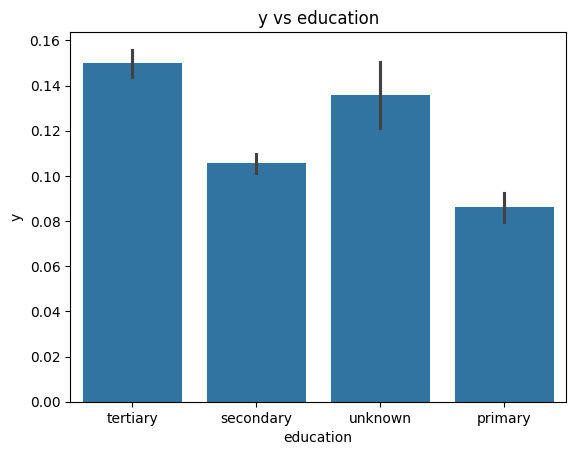

In [158]:
sns.barplot(x= df["education"], y = df["y"].map({"yes":1, "no":0}))
plt.title("y vs education")

##### Most subscribers had tertiary level education while the clients with primary level education formed the group with the least subscribers.

Text(0.5, 1.0, 'job vs y')

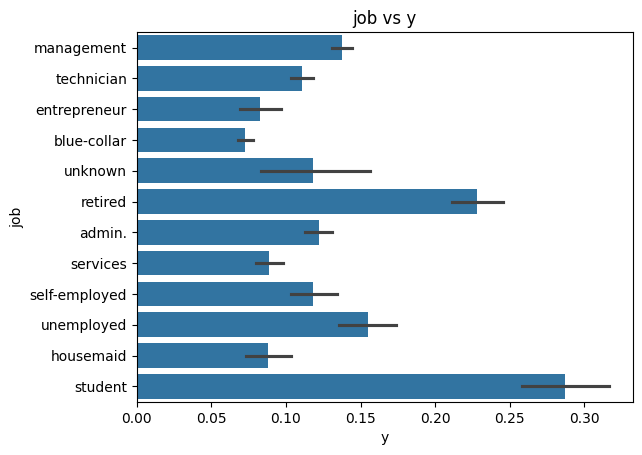

In [159]:
sns.barplot(x = df["y"].map({"yes":1, "no":0}), y = "job", data=df, orient = "h")
plt.title("job vs y")

##### Students form the highest group of subscribers followed by retired clients.

In [164]:
((df["housing_only"] == True) & (df["y"] == "yes")).sum()/((df["y"] == "yes").sum())*100

np.float64(31.57496691245982)

##### 31.57% of subscribers have a housing loan only with the bank.

In [166]:
((df["loan_only"] == True) & (df["y"] == "yes")).sum()/((df["y"] == "yes").sum())*100

np.float64(4.14066931366988)

##### 4.14% of the subscribers have a personal loan only with the bank.

In [168]:
((df["dual_loan"] == True) & (df["y"] == "yes")).sum()/((df["y"] == "yes").sum())*100

np.float64(5.010398941198714)

##### 5.01% of subscibers have two loans with the bank.

Text(0.5, 1.0, 'y vs no loan')

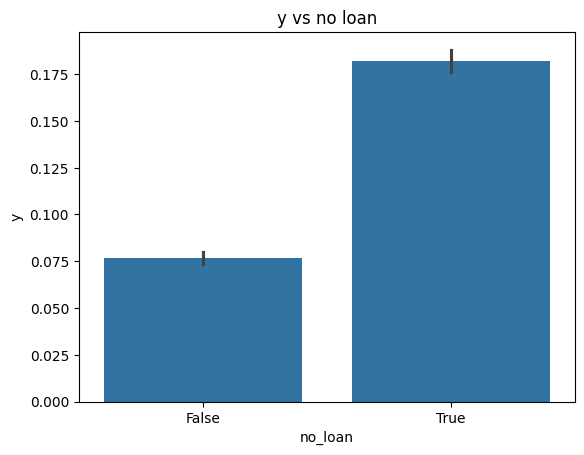

In [169]:
sns.barplot(x= df["no_loan"], y = df["y"].map({"yes":1, "no":0}))
plt.title("y vs no loan")

In [170]:
((df["no_loan"] == True) & (df["y"] == "yes")).sum()/((df["y"] == "yes").sum())*100

np.float64(59.27396483267158)

##### 59.27% of the subscribers have no loan with the bank.

Text(0.5, 1.0, 'y vs default')

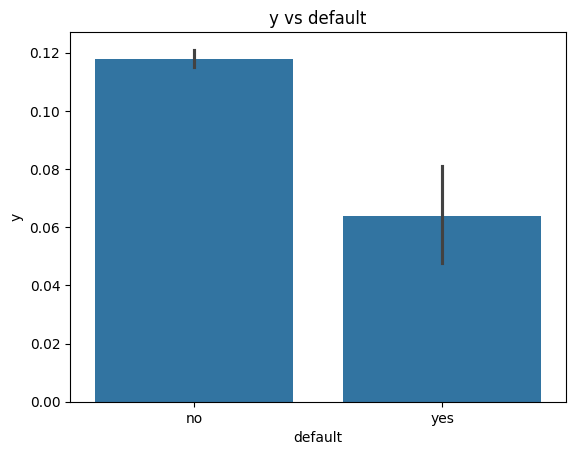

In [172]:
sns.barplot(x = df["default"], y = df["y"].map({"yes":1, "no":0}))
plt.title("y vs default")

In [173]:
((df["y"] == "yes") & (df["default"] == "yes")).sum()/((df["y"] == "yes").sum())*100

np.float64(0.9831726224238986)

##### 0.98% of subscribers are defaulters.

Text(0.5, 1.0, 'Age distribution of subscribers')

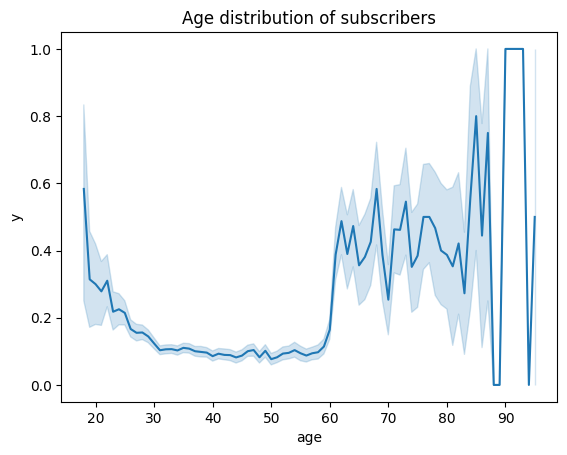

In [177]:
sns.lineplot(x = df["age"], y = df["y"].map({"yes":1, "no":0}))
plt.title("Age distribution of subscribers")

##### The largest group of subscribers are around the ages 20 and 65. There is an outlier at age 90.

In [171]:
df.groupby("y")["balance"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,1303.714969,2974.195473,-8019.0,58.0,417.0,1345.0,102127.0
yes,5289.0,1804.267915,3501.104777,-3058.0,210.0,733.0,2159.0,81204.0


## Data Quality
The data had no blank spaces. However it seems that "unknown" was used to fill in missing data points in these columns: job, education, contact and poutcome.
- Job: 0.64% of clients have job recorded as "unknown".
- Education: 4.12% of clients have education level recorded as "unknown".
- Contact: 28.80% of clients have contact details recorded as "unknown".
- Previous outcome: 81.75% of clients have previous campaign outcome recorded as "unknown".

- The high proportion of "unknown" in contact and previous outcome limits the reliability of those variables for predictive modeling. Future data collection should prioritize complete and accurate recording of client contact details and campaign outcomes.

## Insights
### Overall Default rate : 1.80% of the clients are defaulters.
#### Who are our defaulters?
##### Marital status:
- 15.71% of defaulters are divorced. This could be a reflection of financial strain that divorced clients linked to household restructuring. Marital status could be a relevant factor in credit risk models.
##### Age:
- The highest number of defaulters are aged around 28. This may suggest that young adults navigating career and personal transitions face more repayments difficulties. This shows the importance of considering life stages in credit risk assessment, though further analysis may be needed to find causality.
##### Job:
- Entrepreneurs are highest group of defaulters. This may reflect the inherent financial risk associated with entrepreneurship. One possible mitigation strategy is for the bank to require business plans or other additional documents to be submitted with the loan application.
-  Students show the lowest default rate. However this could be just a reflection of the bank's restrictive policy towards students, meaning only a small group of low risk students are granted loans. The low rate is more a reflection of policy than inherent risk.
##### Education:
- Clients with secondary level education form the highest group of defaulters while clients with tertiary level education form the lowest group of defaulters. This may reflect the difference in income levels across education levels. Education level could serve as a proxy for income stability in risk modeling.
##### Contact:
- 35.5% defaulters were clients that the bank had no contact details for. This limited the bank's ability to send reminders these clients. Stronger record‑keeping and client communication processes are needed.
##### Loans:
- 37.06% of the defaulters are clients that hold housing loans only. This is the highest group of defaulters likely because housing loans are common and are a long term commitment. Housing loan risk management should focus on affordability checks and repayment support.
- 26.01% of defaulters are clients who don't have loans with the bank. This shows that default risk is not limited to loan holders; other financial factors may contribute. Broader client profiling is needed to understand non‑loan defaulters.
##### Balance:
- The mean and median yearly balance of defaulters are negative. This indicates that many defaulters operate with overdrafts or consistently low balances, reflecting weaker financial stability. Balance is a strong predictor of default risk. Clients with negative or very low balances may require closer monitoring, stricter lending criteria, or targeted financial support.

### Overall Subscribers rate : 11.7% of clients contacted subscribed.
- Conversion is modest, highlighting the need for targeted campaigns.

#### Who subscribed?
##### Marital Status:
- Most of the subscribers were single clients. Single clients may be more flexible in financial decisions. Marital status could have an effect on the client's openess to savings products. 
##### Age:
- The largest group of subscribers are around the ages 20 and 65. Younger adults may be starting to save, while older clients may be securing retirement funds. Marketing should tailor messaging to these two life stages.
##### Job:
- Students form the highest group of subscribers followed by retired clients. This is consistent with the ages of subscribers. Students may be attracted by disciplined saving, while retirees value secure returns. Marketing should target university campuses and retirement communities.
##### Education:
- Most subscribers had tertiary level education while the clients with primary level education formed the group with the least subscribers. Higher education may correlate with financial literacy and awareness of savings products. Clients with less education may be less familiar with term deposits or less confident in committing funds. Education level can guide outreach strategy and message tailoring.
##### Loans:
- Most of the subscribers are clients who have no loan with the bank. Clients without debt are more likely to commit to term deposits.Loan status is a strong predictor of subscription likelihood.
##### Balance:
- The mean average annual balance for subscribers is R1804.27. This suggests that term deposits are accessible to clients across income levels. Either the minimum required deposit is relatively low, or the product is designed to appeal to middle‑income clients who want disciplined savings. Marketing should emphasize affordability and accessibility; term deposits are not just for wealthy clients, but for anyone wanting to build savings steadily.
##### Default:
- 0.98% of subscribers are defaulters. While rare, some subscribers carry repayment risk. If term deposits require regular contributions, these clients may need closer monitoring.

#### What did we do to get subscribers?
##### Duration:
- Most of the clients who subscribed were the ones that stayed on the call longer. This may reflect that these clients were interested in the product and enquired more about it. Marketing should allocate more time to calls.
##### Campaign:
- Most clients who were contacted more frequently did not subscribe. This shows that persistence is not always good. Set a cost‑effective cutoff for contact attempts.
##### pdays:
- Most clients that subscribed had been last contacted in over 60 days. Fresh outreach after a longer gap may be more effective.
#### previous:
- Most successful clients were ones that were contacted more frequently before this campaign. This may be a reflection of a good rapport built with clients in previous campaigns.
##### poutcome: 
- 18.49% clients who subscribed had a successful outcome in the previous marketing campaign. However, with 81.75% missing values, this variable is weak. Prior success helps, but data quality limits its predictive power.